In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav_history = pd.read_csv("../data/raw/02_nav_history.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [3]:
print(fund_master.shape)
print(nav_history.shape)
print(benchmark.shape)

(40, 15)
(46000, 3)
(8050, 3)


In [4]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [5]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [6]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [7]:


nav_history["date"] = pd.to_datetime(nav_history["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])



nav_history = nav_history.sort_values(["amfi_code", "date"])
benchmark = benchmark.sort_values(["index_name", "date"])

In [8]:
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


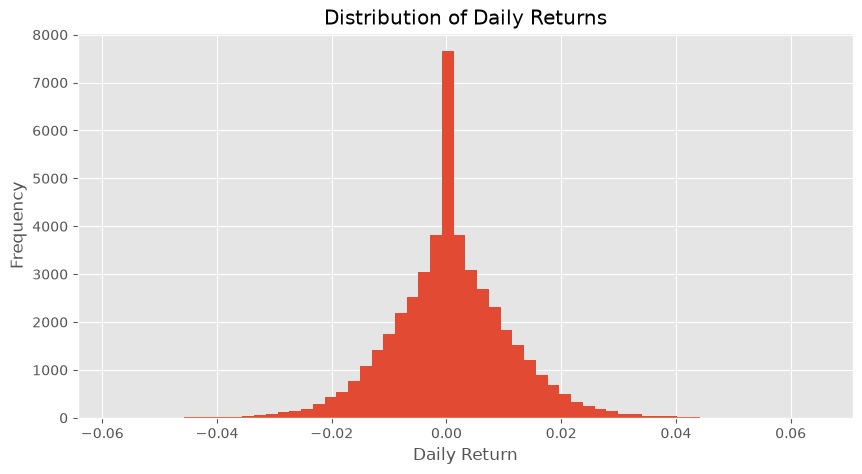

In [9]:
plt.figure(figsize=(10,5))

plt.hist(
    nav_history["daily_return"].dropna(),
    bins=60
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [10]:
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [11]:
nav_history["daily_return"].isna().sum()

np.int64(40)

In [12]:
def calculate_cagr(df, years):

    end_date = df["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    temp = df[df["date"] >= start_date].copy()

    if len(temp) < 2:
        return np.nan

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    cagr = (end_nav / start_nav) ** (1 / years) - 1

    return cagr

In [13]:
cagr_data = []

for amfi in nav_history["amfi_code"].unique():

    fund = nav_history[
        nav_history["amfi_code"] == amfi
    ].sort_values("date")

    cagr_data.append({

        "amfi_code": amfi,

        "cagr_1y": calculate_cagr(fund,1),

        "cagr_3y": calculate_cagr(fund,3),

        "cagr_5y": calculate_cagr(fund,5)

    })

cagr_df = pd.DataFrame(cagr_data)

cagr_df.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [14]:
cagr_df = cagr_df.merge(

    fund_master[["amfi_code","scheme_name"]],

    on="amfi_code",

    how="left"

)

cagr_df.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y,scheme_name
0,100016,-0.022243,0.012926,0.023168,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.037050,0.039164,0.039127,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.239860,-0.041524,0.069533,ABSL Small Cap Fund - Regular - Growth


In [15]:
cagr_df = cagr_df.sort_values(

    "cagr_3y",

    ascending=False

)

cagr_df.head(10)

,amfi_code,cagr_1y,cagr_3y,cagr_5y,scheme_name
16,119094,0.222611,0.351118,0.244453,Axis Midcap Fund - Regular - Growth
34,148567,0.203607,0.340009,0.267993,Mirae Asset Large Cap Fund - Regular - Growth
24,120504,0.130643,0.324874,0.202340,ICICI Pru Bluechip Fund - Direct - Growth
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,0.296047,0.317775,0.283768,ICICI Pru Midcap Fund - Regular - Growth
19,119551,0.604373,0.304565,0.223849,SBI Bluechip Fund - Regular Plan - Growth
30,120843,0.266571,0.295828,0.267425,Kotak Flexicap Fund - Regular - Growth
36,148569,0.397518,0.291789,0.276299,Mirae Asset Tax Saver Fund - Regular - Growth
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth
39,149324,0.651387,0.270004,0.279174,DSP Small Cap Fund - Regular - Growth


In [16]:
cagr_df.to_csv(

    "../reports/cagr_comparison.csv",

    index=False

)

In [17]:
RF = 0.065

def calculate_sharpe(returns):

    returns = returns.dropna()

    if len(returns) == 0:
        return np.nan

    annual_return = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)

    sharpe = (annual_return - RF) / annual_volatility

    return sharpe

In [18]:
sharpe_data = []

for amfi in nav_history["amfi_code"].unique():

    temp = nav_history[
        nav_history["amfi_code"] == amfi
    ]

    sharpe_data.append({

        "amfi_code": amfi,

        "sharpe_ratio": calculate_sharpe(
            temp["daily_return"]
        )

    })

sharpe_df = pd.DataFrame(sharpe_data)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [19]:
sharpe_df = sharpe_df.merge(

    fund_master[["amfi_code","scheme_name"]],

    on="amfi_code",

    how="left"

)

sharpe_df.head()

,amfi_code,sharpe_ratio,scheme_name
0,100016,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.162661,ABSL Small Cap Fund - Regular - Growth


In [20]:
sharpe_df = sharpe_df.sort_values(

    "sharpe_ratio",

    ascending=False

)

sharpe_df.head(10)

,amfi_code,sharpe_ratio,scheme_name
34,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.132122,DSP Midcap Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
24,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


In [21]:
sharpe_df.to_csv(

    "../reports/sharpe_ratio.csv",

    index=False

)

In [22]:
def calculate_sortino(returns):

    returns = returns.dropna()

    if len(returns) == 0:
        return np.nan

    annual_return = returns.mean() * 252

    downside = returns[returns < 0]

    if len(downside) == 0:
        return np.nan

    downside_std = downside.std() * np.sqrt(252)

    sortino = (annual_return - RF) / downside_std

    return sortino

In [23]:
sortino_data = []

for amfi in nav_history["amfi_code"].unique():

    temp = nav_history[
        nav_history["amfi_code"] == amfi
    ]

    sortino_data.append({

        "amfi_code": amfi,

        "sortino_ratio": calculate_sortino(
            temp["daily_return"]
        )

    })

sortino_df = pd.DataFrame(sortino_data)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [24]:
sortino_df = sortino_df.merge(

    fund_master[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

sortino_df.head()

,amfi_code,sortino_ratio,scheme_name
0,100016,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.941821,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.276644,ABSL Small Cap Fund - Regular - Growth


In [25]:
sortino_df = sortino_df.sort_values(

    "sortino_ratio",

    ascending=False

)

sortino_df.head(10)

,amfi_code,sortino_ratio,scheme_name
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.875101,DSP Midcap Fund - Regular - Growth
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth


In [26]:
sortino_df.to_csv(

    "../reports/sortino_ratio.csv",

    index=False

)

In [27]:
benchmark.head(10)

,date,index_name,close_value
3450,2022-01-03,BSE_SMALLCAP,26554.60
3451,2022-01-04,BSE_SMALLCAP,27079.92
3452,2022-01-05,BSE_SMALLCAP,27313.35
3453,2022-01-06,BSE_SMALLCAP,27377.05
3454,2022-01-07,BSE_SMALLCAP,26316.86
3455,2022-01-10,BSE_SMALLCAP,26476.06
3456,2022-01-11,BSE_SMALLCAP,26462.96
3457,2022-01-12,BSE_SMALLCAP,26090.99
3458,2022-01-13,BSE_SMALLCAP,26085.36
3459,2022-01-14,BSE_SMALLCAP,26081.45


In [28]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [29]:
benchmark = benchmark.sort_values(["index_name", "date"])

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [30]:
benchmark_nifty = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

benchmark_nifty.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
1,2022-01-04,NIFTY50,17689.64,0.011253
2,2022-01-05,NIFTY50,17835.05,0.008220
3,2022-01-06,NIFTY50,17878.51,0.002437
4,2022-01-07,NIFTY50,17759.15,-0.006676


In [31]:
def calculate_alpha_beta(fund_returns, benchmark_returns):

    temp = pd.concat(
        [fund_returns, benchmark_returns],
        axis=1
    ).dropna()

    if len(temp) < 2:
        return np.nan, np.nan

    beta, alpha, _, _, _ = linregress(
        temp.iloc[:,1],
        temp.iloc[:,0]
    )

    annual_alpha = alpha * 252

    return annual_alpha, beta

In [32]:
alpha_beta = []

for amfi in nav_history["amfi_code"].unique():

    fund = nav_history[
        nav_history["amfi_code"] == amfi
    ][["date","daily_return"]]

    merged = fund.merge(
        benchmark_nifty[["date","benchmark_return"]],
        on="date",
        how="inner"
    )

    alpha, beta = calculate_alpha_beta(
        merged["daily_return"],
        merged["benchmark_return"]
    )

    alpha_beta.append({

        "amfi_code": amfi,

        "alpha": alpha,

        "beta": beta

    })

alpha_beta_df = pd.DataFrame(alpha_beta)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.036221,-0.025909
1,100025,0.043189,-0.016176
2,100033,0.272343,-0.011200
3,101206,0.213945,0.033814
4,101207,0.108205,-0.059856


In [33]:
alpha_beta_df = alpha_beta_df.merge(

    fund_master[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

alpha_beta_df.head()

,amfi_code,alpha,beta,scheme_name
0,100016,0.036221,-0.025909,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.043189,-0.016176,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.272343,-0.011200,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213945,0.033814,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108205,-0.059856,ABSL Small Cap Fund - Regular - Growth


In [34]:
alpha_beta_df = alpha_beta_df.sort_values(

    "alpha",

    ascending=False

)

alpha_beta_df.head(10)

,amfi_code,alpha,beta,scheme_name
21,119598,0.301114,0.074266,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.298179,0.132608,DSP Small Cap Fund - Regular - Growth
25,120505,0.293014,-0.017391,ICICI Pru Midcap Fund - Regular - Growth
36,148569,0.283473,-0.010201,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,0.272784,-0.008737,Kotak Flexicap Fund - Regular - Growth
2,100033,0.272343,-0.011200,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
34,148567,0.271150,-0.028133,Mirae Asset Large Cap Fund - Regular - Growth
38,149323,0.265836,0.003479,DSP Midcap Fund - Regular - Growth
16,119094,0.259971,-0.059868,Axis Midcap Fund - Regular - Growth
19,119551,0.232196,-0.056045,SBI Bluechip Fund - Regular Plan - Growth


In [35]:
alpha_beta_df.to_csv(

    "../reports/alpha_beta.csv",

    index=False

)

In [36]:
def calculate_max_drawdown(df):

    temp = df.sort_values("date").copy()

    temp["running_max"] = temp["nav"].cummax()

    temp["drawdown"] = (
        temp["nav"] / temp["running_max"]
    ) - 1

    max_dd = temp["drawdown"].min()

    max_date = temp.loc[
        temp["drawdown"].idxmin(),
        "date"
    ]

    return max_dd, max_date

In [37]:
drawdown_data = []

for amfi in nav_history["amfi_code"].unique():

    fund = nav_history[
        nav_history["amfi_code"] == amfi
    ]

    max_dd, dd_date = calculate_max_drawdown(fund)

    drawdown_data.append({

        "amfi_code": amfi,

        "max_drawdown": max_dd,

        "drawdown_date": dd_date

    })

drawdown_df = pd.DataFrame(drawdown_data)

drawdown_df.head()

,amfi_code,max_drawdown,drawdown_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [38]:
drawdown_df = drawdown_df.merge(

    fund_master[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

drawdown_df.head()

,amfi_code,max_drawdown,drawdown_date,scheme_name
0,100016,-0.247344,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth


In [39]:
drawdown_df = drawdown_df.sort_values(

    "max_drawdown",

    ascending=False

)

drawdown_df.head(10)

,amfi_code,max_drawdown,drawdown_date,scheme_name
27,120507,-0.000977,2025-10-20,ICICI Pru Liquid Fund - Regular - Growth
31,120844,-0.001163,2024-04-30,Kotak Liquid Fund - Regular - Growth
5,101208,-0.001622,2023-09-12,ABSL Liquid Fund - Regular - Growth
1,100025,-0.043083,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth
18,119120,-0.043287,2025-04-01,SBI Magnum Gilt Fund - Regular Plan - Growth
13,118636,-0.083164,2024-02-09,Nippon India Gilt Securities Fund - Regular - ...
6,102885,-0.108599,2022-03-29,UTI Nifty 50 Index Fund - Regular - Growth
34,148567,-0.112657,2023-10-20,Mirae Asset Large Cap Fund - Regular - Growth
3,101206,-0.112916,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth
12,118635,-0.116506,2022-06-09,Nippon India ETF Nifty 50 BeES


In [40]:
drawdown_df.to_csv(

    "../reports/max_drawdown.csv",

    index=False

)

In [41]:
scorecard = cagr_df[
    ["amfi_code", "scheme_name", "cagr_3y"]
].copy()

scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "sharpe_ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code", "max_drawdown"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    fund_master[["amfi_code", "expense_ratio_pct"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,cagr_3y,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct
0,119094,Axis Midcap Fund - Regular - Growth,0.351118,0.998231,0.259971,-0.209609,1.38
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.340009,1.448291,0.271150,-0.112657,1.46
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.324874,1.026524,0.212094,-0.125883,0.80
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.324425,1.093699,0.272343,-0.162172,1.38
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.317775,1.180101,0.293014,-0.181885,1.36


In [42]:
scorecard["return_rank"] = scorecard["cagr_3y"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False
)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(
    ascending=False
)

scorecard.head()

,amfi_code,scheme_name,cagr_3y,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank
0,119094,Axis Midcap Fund - Regular - Growth,0.351118,0.998231,0.259971,-0.209609,1.38,1.0,11.0,9.0,17.0,28.0
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.340009,1.448291,0.271150,-0.112657,1.46,2.0,1.0,7.0,23.0,8.0
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.324874,1.026524,0.212094,-0.125883,0.80,3.0,10.0,13.0,12.0,12.0
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.324425,1.093699,0.272343,-0.162172,1.38,4.0,7.0,6.0,17.0,20.0
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.317775,1.180101,0.293014,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0


In [43]:
scorecard["score"] = (

    0.30 * scorecard["return_rank"]

    + 0.25 * scorecard["sharpe_rank"]

    + 0.20 * scorecard["alpha_rank"]

    + 0.15 * scorecard["expense_rank"]

    + 0.10 * scorecard["drawdown_rank"]

)

In [44]:
scorecard = scorecard.sort_values(
    "score",
    ascending=True
)

scorecard.head(10)

,amfi_code,scheme_name,cagr_3y,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,score
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.340009,1.448291,0.271150,-0.112657,1.46,2.0,1.0,7.0,23.0,8.0,6.500
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.317775,1.180101,0.293014,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0,8.100
6,120843,Kotak Flexicap Fund - Regular - Growth,0.295828,1.306744,0.272784,-0.129740,1.45,7.0,2.0,5.0,22.0,13.0,8.200
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.324425,1.093699,0.272343,-0.162172,1.38,4.0,7.0,6.0,17.0,20.0,8.700
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.324874,1.026524,0.212094,-0.125883,0.80,3.0,10.0,13.0,12.0,12.0,9.000
0,119094,Axis Midcap Fund - Regular - Growth,0.351118,0.998231,0.259971,-0.209609,1.38,1.0,11.0,9.0,17.0,28.0,10.200
5,119551,SBI Bluechip Fund - Regular Plan - Growth,0.304565,1.208267,0.232196,-0.150124,1.54,6.0,4.0,10.0,30.5,17.0,11.075
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.291789,1.234930,0.283473,-0.163967,1.60,8.0,3.0,4.0,36.5,21.0,11.525
8,101206,ABSL Frontline Equity Fund - Regular - Growth,0.289677,1.027213,0.213945,-0.112916,1.60,9.0,9.0,12.0,36.5,9.0,13.725
11,119598,SBI Small Cap Fund - Regular Plan - Growth,0.266699,0.945308,0.301114,-0.287060,1.43,12.0,14.0,1.0,21.0,36.0,14.050


In [45]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [46]:
top5 = scorecard.head(5)

top5

,amfi_code,scheme_name,cagr_3y,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,score
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.340009,1.448291,0.271150,-0.112657,1.46,2.0,1.0,7.0,23.0,8.0,6.5
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.317775,1.180101,0.293014,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0,8.1
6,120843,Kotak Flexicap Fund - Regular - Growth,0.295828,1.306744,0.272784,-0.129740,1.45,7.0,2.0,5.0,22.0,13.0,8.2
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.324425,1.093699,0.272343,-0.162172,1.38,4.0,7.0,6.0,17.0,20.0,8.7
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.324874,1.026524,0.212094,-0.125883,0.80,3.0,10.0,13.0,12.0,12.0,9.0


In [47]:
benchmark_plot = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

benchmark_plot = benchmark_plot.sort_values("date")

benchmark_plot["benchmark_growth"] = (
    benchmark_plot["close_value"]
    / benchmark_plot["close_value"].iloc[0]
)

benchmark_plot.head()

,date,index_name,close_value,benchmark_return,benchmark_growth
0,2022-01-03,NIFTY50,17492.79,NaN,1.000000
1,2022-01-04,NIFTY50,17689.64,0.011253,1.011253
2,2022-01-05,NIFTY50,17835.05,0.008220,1.019566
3,2022-01-06,NIFTY50,17878.51,0.002437,1.022050
4,2022-01-07,NIFTY50,17759.15,-0.006676,1.015227


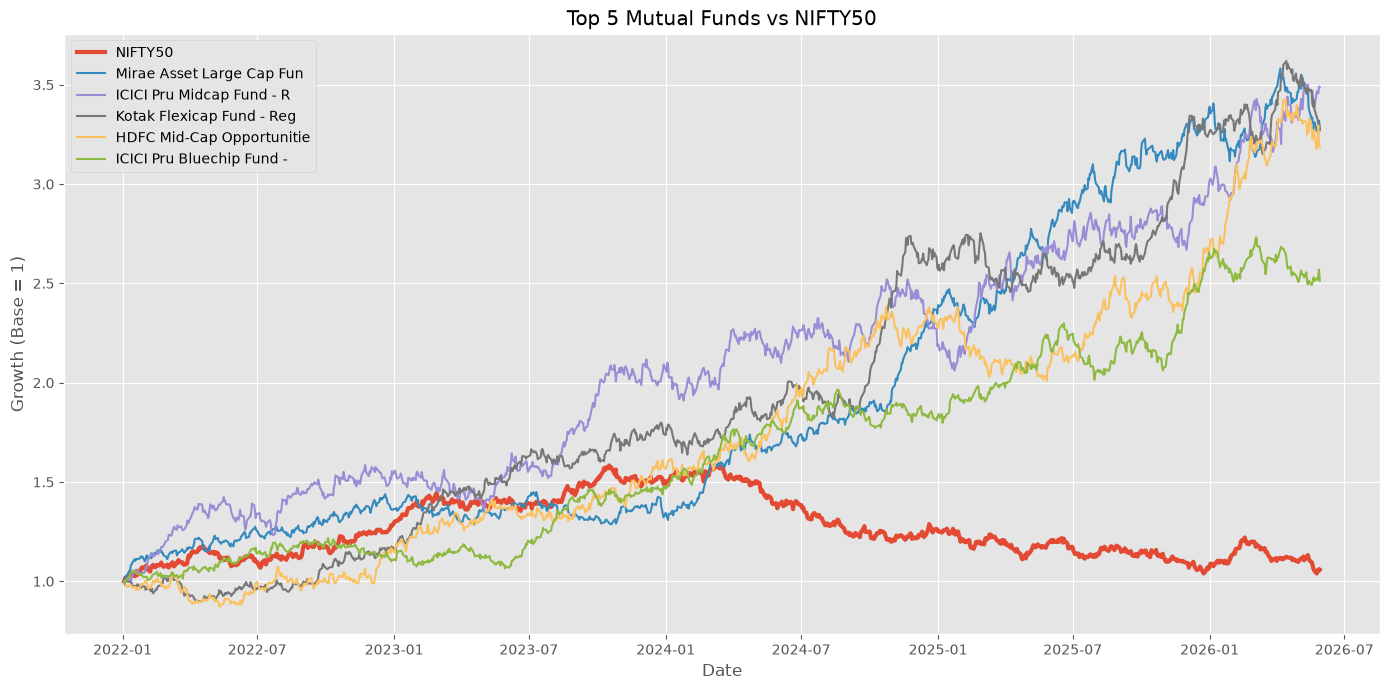

In [48]:
plt.figure(figsize=(14,7))

plt.plot(
    benchmark_plot["date"],
    benchmark_plot["benchmark_growth"],
    label="NIFTY50",
    linewidth=3
)

for amfi in top5["amfi_code"]:

    fund = nav_history[
        nav_history["amfi_code"] == amfi
    ].copy()

    fund = fund.sort_values("date")

    growth = fund["nav"] / fund["nav"].iloc[0]

    name = fund_master.loc[
        fund_master["amfi_code"] == amfi,
        "scheme_name"
    ].values[0]

    plt.plot(
        fund["date"],
        growth,
        label=name[:25]
    )

plt.title("Top 5 Mutual Funds vs NIFTY50")
plt.xlabel("Date")
plt.ylabel("Growth (Base = 1)")
plt.legend()

plt.tight_layout()

plt.show()

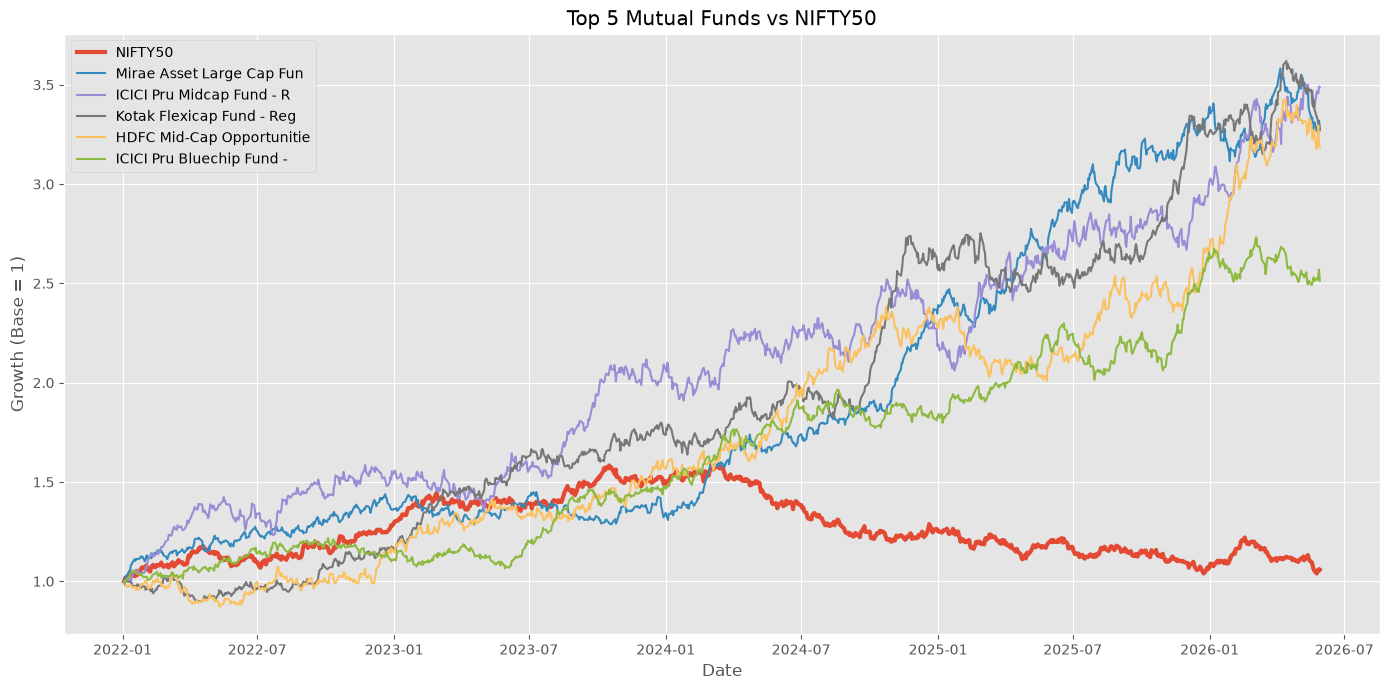

In [49]:
plt.figure(figsize=(14,7))

plt.plot(
    benchmark_plot["date"],
    benchmark_plot["benchmark_growth"],
    label="NIFTY50",
    linewidth=3
)

for amfi in top5["amfi_code"]:

    fund = nav_history[
        nav_history["amfi_code"] == amfi
    ].copy()

    fund = fund.sort_values("date")

    growth = fund["nav"] / fund["nav"].iloc[0]

    name = fund_master.loc[
        fund_master["amfi_code"] == amfi,
        "scheme_name"
    ].values[0]

    plt.plot(
        fund["date"],
        growth,
        label=name[:25]
    )

plt.title("Top 5 Mutual Funds vs NIFTY50")
plt.xlabel("Date")
plt.ylabel("Growth (Base = 1)")
plt.legend()

plt.tight_layout()

plt.savefig("../reports/benchmark_comparison.png", dpi=300)

plt.show()